In [33]:
from fastai.vision.all import *

print("FastAI installed successfully")

FastAI installed successfully


In [34]:
import fastai
print(fastai.__version__)

2.8.7


In [35]:
# !pip install duckduckgo-search this is deprec!ated 

# !pip uninstall duckduckgo-search
# !pip install ddgs

The basic steps we'll take are:

Use DuckDuckGo to search for images of "bird photos"
Use DuckDuckGo to search for images of "forest photos"
Fine-tune a pretrained neural network to recognise these two groups
Try running this model on a picture of a bird and see if it works.

Step 1: Download images of birds and non-birds

In [43]:
# new api and how to use to get images
from ddgs import DDGS
from fastcore.all import *
from itertools import islice

def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = ddgs.images(query=keywords,region='us-en')
        return L(r['image'] for r in islice(results, max_images))    
    
    
import time, json

Let's start by searching for a bird photo and seeing what kind of result we get. We'll start by getting URLs from a search:

In [44]:
#NB: `search_images` depends on duckduckgo.com, which doesn't always return correct responses.
#    If you get a JSON error, just try running it again (it may take a couple of tries).
urls = search_images('bird photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/45851/bird-blue-cristata-cyanocitta-45851.jpeg?cs=srgb&dl=pexels-pixabay-45851.jpg&fm=jpg'

...and then download a URL and take a look at it:

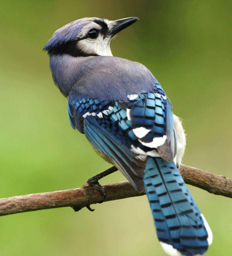

In [45]:
from fastdownload import download_url
dest = 'bird.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

Now let's do the same with "fish photos":

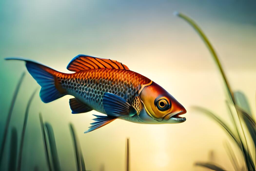

In [39]:
download_url(search_images('fish photos', max_images=1)[0], 'fish.jpg', show_progress=False)
Image.open('fish.jpg').to_thumb(256,256)

Our searches seem to be giving reasonable results, so let's grab a few examples of each of "bird" and "forest" photos, and save each group of photos to a different folder:

In [47]:
searches = 'fish','bird'
path = Path('bird_or_not')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

Step 2: Train our model


Some photos might not download correctly which could cause our model training to fail, so we'll remove them:

In [41]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0


To train a model, we'll need DataLoaders, which is an object that contains a training set (the images used to create a model) and a validation set (the images used to check the accuracy of a model -- not used during training). In fastai we can create that easily using a DataBlock, and view sample images from it:

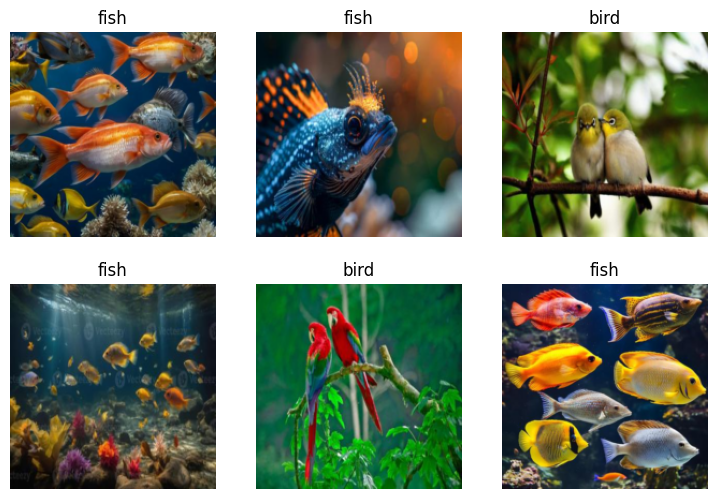

In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32) # this batch size can be reduces if we have less image other wise it will give the error

dls.show_batch(max_n=6)

Here what each of the DataBlock parameters means:

blocks=(ImageBlock, CategoryBlock),
The inputs to our model are images, and the outputs are categories (in this case, "bird" or "forest").

get_items=get_image_files, 
To find all the inputs to our model, run the get_image_files function (which returns a list of all image files in a path).

splitter=RandomSplitter(valid_pct=0.2, seed=42),
Split the data into training and validation sets randomly, using 20% of the data for the validation set.

get_y=parent_label,
The labels (y values) is the name of the parent of each file (i.e. the name of the folder they're in, which will be bird or forest).

item_tfms=[Resize(192, method='squish')]
Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is resnet18. You can train this in a few minutes, even on a CPU! (On a GPU, it generally takes under 10 seconds...)

fastai comes with a helpful fine_tune() method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

In [64]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.545525,2.862767,0.600000,00:00


epoch,train_loss,valid_loss,error_rate,time
0,1.412076,1.732259,0.600000,00:00
1,1.010925,0.248477,0.133333,00:00
2,0.771868,0.033517,0.000000,00:00


Here's what the numbers mean:

*   **`epoch`**: One complete pass through your entire training dataset.
*   **`train_loss`**: The model's average error on the training data for that epoch. It should generally decrease.
*   **`valid_loss`**: The model's average error on the unseen validation data. This measures generalization. The best model is usually when `valid_loss` is lowest.
*   **`error_rate`**: The fraction of validation images classified incorrectly (e.g., 0.333333 = 33.3% wrong). Lower is better.
*   **`time`**: Time taken for that epoch.

**To compare runs:**
The **best run** has the **lowest `valid_loss` and `error_rate`**. In your second run, both `valid_loss` (1.234858) and `error_rate` (0.333333) improved compared to the first run (3.327503 and 0.400000), so it's better.



Generally when I run this I see 100% accuracy on the validation set (although it might vary a bit from run to run).

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the pretrained model), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in imagenet, and widely-used computer vision dataset with images covering 1000 categories) For details on fine-tuning and why it's important, check out the free fast.ai course.

Step 3: Use our model (and build your own!)

Let's see what our model thinks about that bird we downloaded at the start:

In [65]:
is_bird,_,probs = learn.predict(PILImage.create('fish.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

This is a: fish.
Probability it's a bird: 0.0003


Good job, resnet18. :)

So, as you see, in the space of a few years, creating computer vision classification models has gone from "so hard it's a joke" to "trivially easy and free"!

It's not just in computer vision. Thanks to deep learning, computers can now do many things which seemed impossible just a few years ago, including creating amazing artworks, and explaining jokes. It's moving so fast that even experts in the field have trouble predicting how it's going to impact society in the coming years.

One thing is clear -- it's important that we all do our best to understand this technology, because otherwise we'll get left behind!

Now it's your turn. Click "Copy & Edit" and try creating your own image classifier using your own image searches!

If you enjoyed this, please consider clicking the "upvote" button in the top-right -- it's very encouraging to us notebook authors to know when people appreciate our work.

The model is **not told to classify fish by the `DataBlock` or `dataloader` code alone**.

The `DataBlock` only defines *how* to load and preprocess the data (get image files, use parent folder as label, resize, split data). It does **not** perform any training.

The model learns to classify fish (or not) when you later call a training method like `learn.fit()` or `learn.fine_tune()` on a `Learner` object that uses these `dls`. The training process uses the data prepared by `dls` to adjust the model's weights.

```python
# This is where training happens
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(3) # <-- The model learns here
```
The code performs **transfer learning** to train a model to classify images:

1.  `vision_learner(dls, resnet18, metrics=error_rate)`:
    *   Creates a neural network using the `resnet18` architecture, pre-trained on millions of images (ImageNet).
    *   Adapts this pre-trained model to your specific dataset (`dls`) and labels (e.g., "bird" vs "not_bird").
    *   Sets `error_rate` as the metric to evaluate performance.

2.  `learn.fine_tune(3)`:
    *   **First**, it trains only the newly added final layers (the "head") while keeping the pre-trained layers (the "body") frozen. This quickly adapts the model to your data.
    *   **Then**, it unfreezes all layers and trains the entire model for 3 epochs with a lower learning rate, fine-tuning the pre-trained features for your specific task.

This approach is fast and effective, especially with smaller datasets.
The model predicts "bird" for your `fish.jpg` image likely because:

1.  **Class Imbalance**: Your training data has significantly more "bird" images than "not_bird" images. The model learns to predict the majority class ("bird") as a default to minimize loss.
2.  **Insufficient Training**: The model may not have learned meaningful features to distinguish between "bird" and "not_bird" and is simply guessing the most common class.
3.  **Poor Data Quality**: The "not_bird" images might not be diverse enough (e.g., all are blank backgrounds), making "bird" the only complex pattern the model sees.

To fix this, ensure your "not_bird" folder contains a diverse set of images (like fish, cars, people) and check the balance between the two classes.





In [58]:
dls.vocab

['bird', 'fish']

In [59]:
dls.vocab.o2i

{'bird': 0, 'fish': 1}

In [66]:
is_fish,_,probs = learn.predict(PILImage.create('fish.jpg'))
print(f"This is a: {is_fish}.")
print(f"Probability it's a fish: {probs[1]:.4f}")

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

This is a: fish.
Probability it's a fish: 0.9997


In [80]:
is_fish,_,probs = learn.predict(PILImage.create('test/fish/fish_9.jpg'))
print(f"This is a: {is_fish}.")
print(f"Probability it's a fish: {probs[1]:.4f}")

This is a: fish.
Probability it's a fish: 0.9913


You can check the class labels and their indices using `dls.vocab`.

*   `dls.vocab`: Shows the list of class names (e.g., `['bird', 'fish']`).
*   `dls.vocab.o2i`: Shows a dictionary mapping class names to their indices (e.g., `{'bird': 0, 'fish': 1}`).

This tells you exactly what `is_fish` will be and the correct index for `probs`.


Yes, the labels like `is_bird` or `is_fish` are determined **automatically** by the `parent_label` function.

It reads the **folder names** where your images are stored (e.g., `bird` and `fish`). These folder names become the class labels used for training and prediction. The model learns to predict whichever label matches the folder name.




To test on multiple images and calculate accuracy, create a test_dl and use get_preds():

In [72]:
from ddgs import DDGS
from fastcore.all import *
import requests
import os

def search_and_download_images(keywords, max_images=10):
    # Create the 'test' folder
    os.makedirs('test', exist_ok=True)
    
    with DDGS() as ddgs:
        # Get image URLs
        results = ddgs.images(query=keywords, max_results=max_images)
        urls = L(r['image'] for r in results)
        
        # Download each image
        for i, url in enumerate(urls):
            try:
                response = requests.get(url, timeout=10)
                response.raise_for_status()
                filename = f'test/{keywords}_{i}.jpg'
                with open(filename, 'wb') as f:
                    f.write(response.content)
                print(f"Downloaded: {filename}")
            except Exception as e:
                print(f"Failed to download {url}: {e}")

# Download fish and bird images
search_and_download_images('fish', max_images=10)
search_and_download_images('bird', max_images=10)

print("Download complete.")   

Downloaded: test/fish_0.jpg
Downloaded: test/fish_1.jpg
Downloaded: test/fish_2.jpg
Downloaded: test/fish_3.jpg
Downloaded: test/fish_4.jpg
Downloaded: test/fish_5.jpg
Downloaded: test/fish_6.jpg
Downloaded: test/fish_7.jpg
Downloaded: test/fish_8.jpg
Downloaded: test/fish_9.jpg
Downloaded: test/bird_0.jpg
Downloaded: test/bird_1.jpg
Downloaded: test/bird_2.jpg
Downloaded: test/bird_3.jpg
Downloaded: test/bird_4.jpg
Downloaded: test/bird_5.jpg
Downloaded: test/bird_6.jpg
Failed to download https://www.slj.com/binaries/content/gallery/Jlibrary/2025/04/song-bird-by-maheera-kulsoom.png: 403 Client Error: Forbidden for url: https://www.slj.com/binaries/content/gallery/Jlibrary/2025/04/song-bird-by-maheera-kulsoom.png
Failed to download https://fwdlife.in/wp-content/uploads/2018/05/birds.jpg: 406 Client Error: Not Acceptable for url: https://fwdlife.in/wp-content/uploads/2018/05/birds.jpg
Downloaded: test/bird_9.jpg
Download complete.


In [76]:
# Create test dataloader from the 'test' folder structure
test_dl = learn.dls.test_dl(get_image_files('test'), with_labels=True)

# Get predictions and true labels
preds, targs = learn.get_preds(dl=test_dl)

# Calculate accuracy
accuracy = (preds.argmax(dim=1) == targs).float().mean()
print(f"Test Accuracy: {accuracy:.4f}")   

Test Accuracy: 0.9444
